Calculate all the mountpoints from the data  first 3 directory.. groupby them

3 most important  relationships 

- events that interfere with each other
    - across storage targets
    - across type of operations (data,metadata)

- Events that contribute towards an IO phase 
    - across storage targets
    - across compute target (hostname)
    - across types of operations. (read/write/metadata)
    
- Events that dictates the makespan of the workload
    - import processes (size)
    - important apps
    - important files
    - important dirs

- Graph Technique creation and metric
    - how create graph? undirected vs directed 
        - what kind of relationship will they give?
    - what metric to apply? and what does it give ?
        - deg/betweeness what does it tell?

- Mapping of every I/O relationship?
    - eg. degree/overlap can show burst ... 
    



## Technique 1:
### Graph 1: (Overlap Graph : Undirected)


### a. What are the I/O charactrastics we are trying to find?
Can we identify I/O events which suffer from the  most I/O interferences. To do so we calculate IF which is cost of IO event by cost of isolated IO event. Then we use this metric to identify the ideal parallelism of a storage target by observing the IF per transfer size.



Using this technique we are trying to identify the correaltion between saturation of mount point and duration of I/O access across different request sizes. To quantify this correlationship, we calculate the interference factor (IF) for each I/O events and perform characterization of workload based on the pattern of I/O events' IF.

We also identify potential region for I/O performance improvement by identifying the events that are below saturation range for mount points. 


### b. *How do we find these Characteristics? (methodology)* 
How they can be solved by graph technique?
Identifying IF can be represented as a graph of such that events are vertices and edges represent overlap between two events. In such a graph, the degree of each vertex represents number of events interfering with that event. To create .....

**Graph creation**: We model the I/O traces as a graph where each edge between two I/O events indicates a time overlap between the requests. Since the order of events is irrelevant in this case (i.e., event A overlapping with event B is equivalent to event B overlapping with event A), we treat the graph as undirected. The degree of an event in this graph represents the number of overlapping requests associated with that event. 

**Distributed degree calculation**: Since our traces are large, with millions of nodes, traditional graph representation becomes inefficient, even for basic tasks like computing the degree of a node. To address this, we use DFAnalyzer to segment the traces into multiple time ranges, grouping requests that occur within the same range. This approach improves our computation by: (a) reducing the search space for degree calculations and (b) enabling distributed computation, as events within different time ranges can be processed in parallel.


**IF calculation**: Assuming that all layers in the I/O stack are functioning optimally, I/O requests of the same size directed to the same mount point should take a consistent amount of time to complete. However, when multiple requests are made concurrently, parallel file systems (PFS) can handle these requests concurrently. Yet, if PFS becomes saturated, it may lead to contention ampng these request, causing delays in processing. it can lead to delays in processing these requests. We quantify this delay and refer to it as the Interference Factor for the request.

To calculate the Interference Factor (IF), we first identify the event with the least overlap within each group, based on size and mount point, and use its duration as the reference duration. For each event in the group, we then compute the ratio of its duration to the reference duration, and this ratio is defined as the Interference Factor for that event.


### c. What do we see? (results)
We can look tf and deg and identify use the IF as correlation value.



Heatmap below shows the correlation matrix 

In [80]:
# Import and load computed data

import pandas as pd
import yaml
import sys
import matplotlib.pyplot as plt
import seaborn as sns 
import networkx as nx



app_name = "mummi"
cp_dir = "/p/lustre2/pandey2/cp_dir"

with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    dlp_yaml = yaml.safe_load(file)
    app_root = dlp_yaml["app"]
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 
from dfanalyzer.plots import GrepIOPlots

events_obj = DFGrepInterference(app_name=app_name,  cp_dir = cp_dir, existing=True)
size_bins = [
0, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288,
1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728,
268435456, 536870912, 1073741824, float('inf')
]
size_labels = [
'<512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
'64-128KB', '128-256KB', '256-512KB', '512KB-1MB', '1-2MB', '2-4MB', '4-8MB',
'8-16MB', '16-32MB', '32-64MB', '64-128MB', '128-256MB', '256-512MB', '512MB-1GB', '>1GB'
]

degree_bins = [0,2,4,8,16,32,64,float('inf')]
degree_labels = ['<2','2-4','4-8','8-16', '16-32', '32-64','>64']


inter = events_obj.inter.compute()
inter['IF_val'] = pd.cut(inter['interference'],
                 bins=[0, 0.1, 0.25, 0.5, 0.75, 1, float('inf')],
                 labels=[5, 4, 3, 2, 1, 0])
plot = GrepIOPlots()


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


In [29]:
def hmap(mp=None, df=None, size_bins=[], size_labels=[], degree_bins=[], degree_labels = []):
    # df= inter.compute()
    if mp:
        df= df[df['mount_point']==mp]
    else:
        mp = "All Mount Points"
    # size_bins, size_labels, degree_bins, degree_labels = binned_category()
    df['size_category'] = pd.cut(df['size'], bins=size_bins, labels=size_labels, right=False)
    df['deg_category'] = pd.cut(df['deg_caller'], bins=degree_bins, labels=degree_labels, right=False)
    df['IF_val'] = df['IF_val'].astype(float)
    all_combinations = pd.MultiIndex.from_product([df['size_category'].unique(), df['deg_category'].unique()], names=['size_category', 'deg_category'])
    merged = pd.merge(df, pd.DataFrame(index=all_combinations).reset_index(), on=['size_category', 'deg_category'], how='left')
    grouped = merged.groupby(['size_category', 'deg_category']).agg({'IF_val': 'mean'}).reset_index()
    pivot_table = grouped.pivot(index='size_category', columns='deg_category', values='IF_val').fillna(-1)
    # Create heatmap using seaborn
    plt.figure(figsize=(6, 6))
    sns.heatmap(pivot_table, annot=False, cmap='viridis', fmt='.1f', linewidths=.5, vmin=-1, vmax=5)
    plt.title(f'Average Interference Heatmap {mp}')
    plt.xlabel('Degrees')
    plt.ylabel('Sizes')
    plt.show()


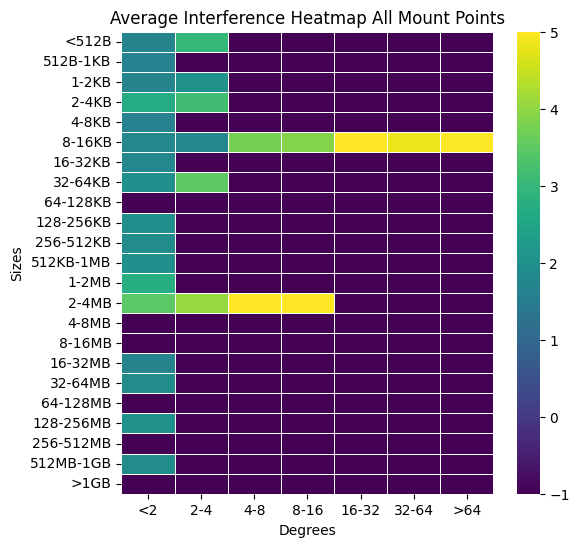

In [33]:
hmap(df=inter, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

## Technique 1.1 (Storage Target Views)
Here, we will see how the IF varies across mount points

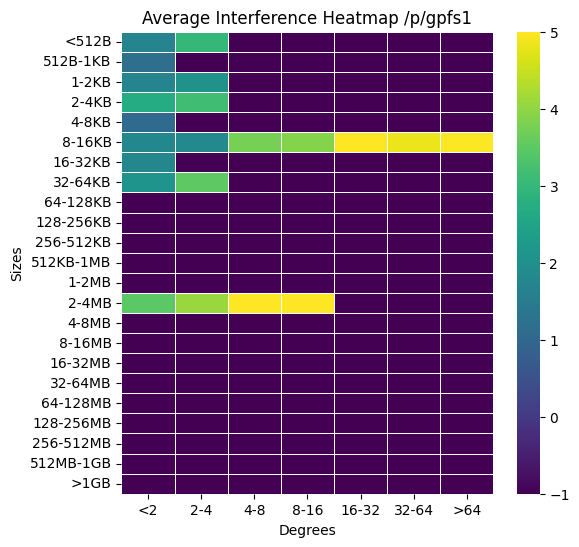

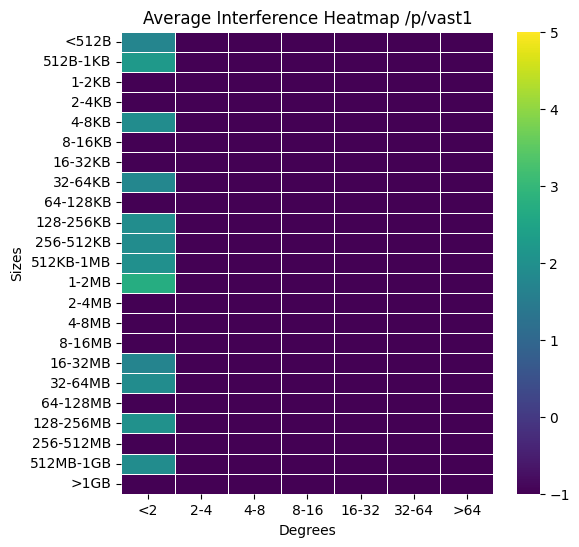

In [31]:

hmap(mp='/p/gpfs1',df=inter, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap(mp='/p/vast1',df=inter, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

## Technique 1.2 (Read Events)
Here we will see how the interference varies across read events

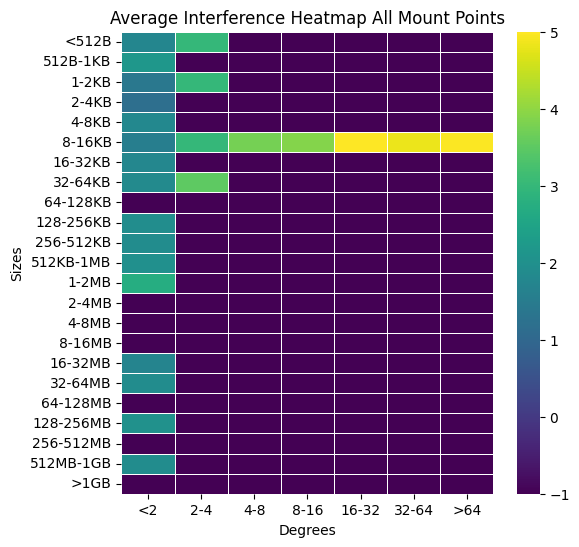

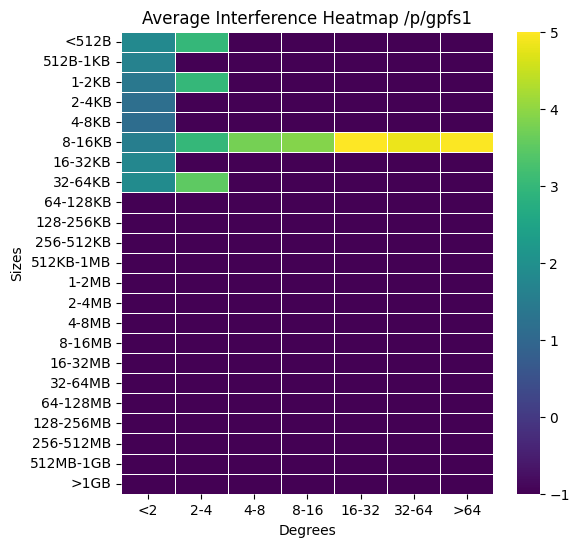

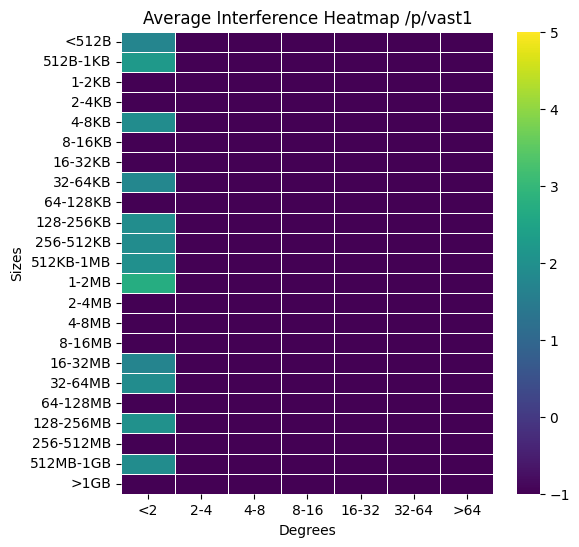

In [39]:
read_df = inter.query('name == "read"')
hmap(df=read_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap(mp = '/p/gpfs1',df=read_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap(mp = '/p/vast1',df=read_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)


## Technique 1.3 (Write Events)
Here we will see how the intererence varies across write events


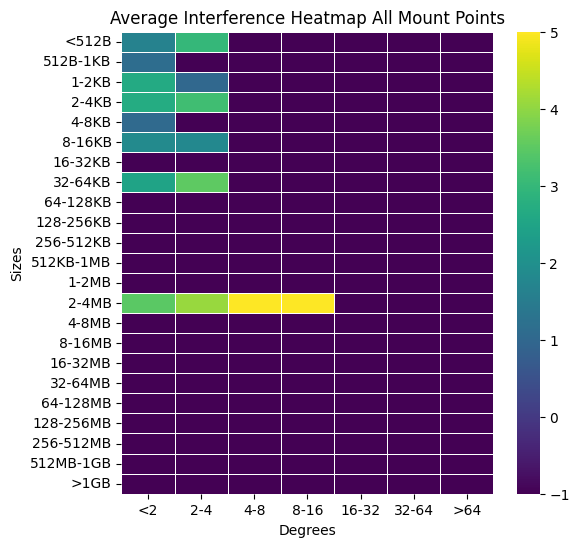

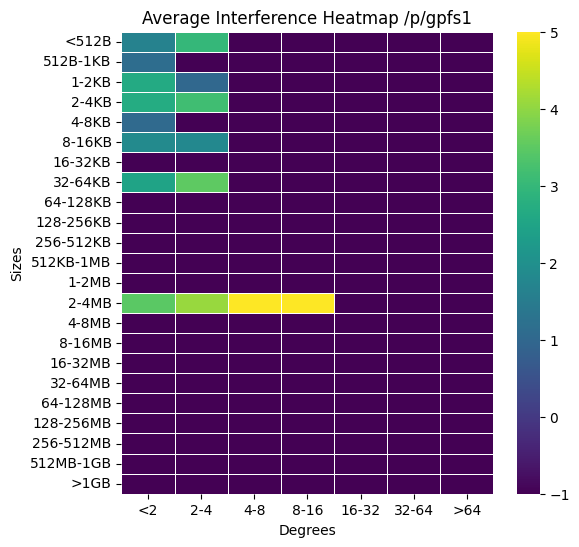

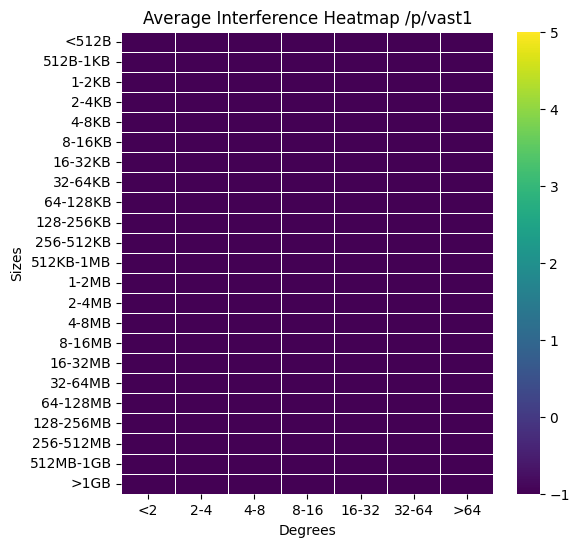

In [40]:
write_df = inter.query('name == "write"')
hmap(df=write_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap(mp = '/p/gpfs1',df=write_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap(mp = '/p/vast1',df=write_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)


## Technique 2 
**Graph Used**: Overlap Graph from Technique 1. Defination of graph, degree and  

### a. *What are the I/O charactrastics we are trying to find?*
We want to idenitify the phases within the workloads which are more data intensive than others. This is also called as IO bursts within the workload. 

We are aiming to identify periods of I/O bursts within the workload execution. These bursts represent intense input/output activity that can lead to congestion or bottlenecks in the system. Our technique focuses on detecting these critical characteristics to better understand and manage workload's behavior.


### b. *How do we find these Characteristics? (methodology)* 
I/O bursts arise when multiple processes simultaneously access the same storage location. 

This characteristic can be identified through the following graph technique 1. with different metric which is degree...

 By calculating the average degree of events over various time ranges in the graph, we capture the number of concurrent access requests. A higher average degree signifies increased concurrent access requests, thereby highlighting more significant I/O bursts within those time ranges

In [70]:
def plot_avg_deg(inter):
    # 1. Group by `trange` and compute the average deg_caller for the entire DataFrame
    overall_avg = inter.groupby('trange')['deg_caller'].mean().reset_index()

    # 2. Filter for `name == "read"` and compute the average deg_caller by `trange`
    read_avg = inter[inter['name'] == 'read'].groupby('trange')['deg_caller'].mean().reset_index()

    # 3. Filter for `name == "write"` and compute the average deg_caller by `trange`
    write_avg = inter[inter['name'] == 'write'].groupby('trange')['deg_caller'].mean().reset_index()

    # Plotting
    plt.figure(figsize=(10, 6))

    # Plot the overall average deg_caller
    plt.plot(overall_avg['trange'], overall_avg['deg_caller'], label='Overall Avg',linestyle = '--', marker='o')

    # Plot the read average deg_caller
    plt.plot(read_avg['trange'], read_avg['deg_caller'], label='Read Avg',linestyle = '--', marker='o')

    # Plot the write average deg_caller
    plt.plot(write_avg['trange'], write_avg['deg_caller'], label='Write Avg', linestyle = '--', marker='o')
    # Customize plot to show the actual range of trange
    # inter['trange'].max()
    plt.xlim(0, 10)  # Set x-axis limits to the min and max of trange
    plt.xlabel('trange')
    plt.ylabel('Average Degree')
    plt.title('Average Degree by trange')
    plt.legend()
    # Show the plot
    plt.tight_layout()
    plt.show()

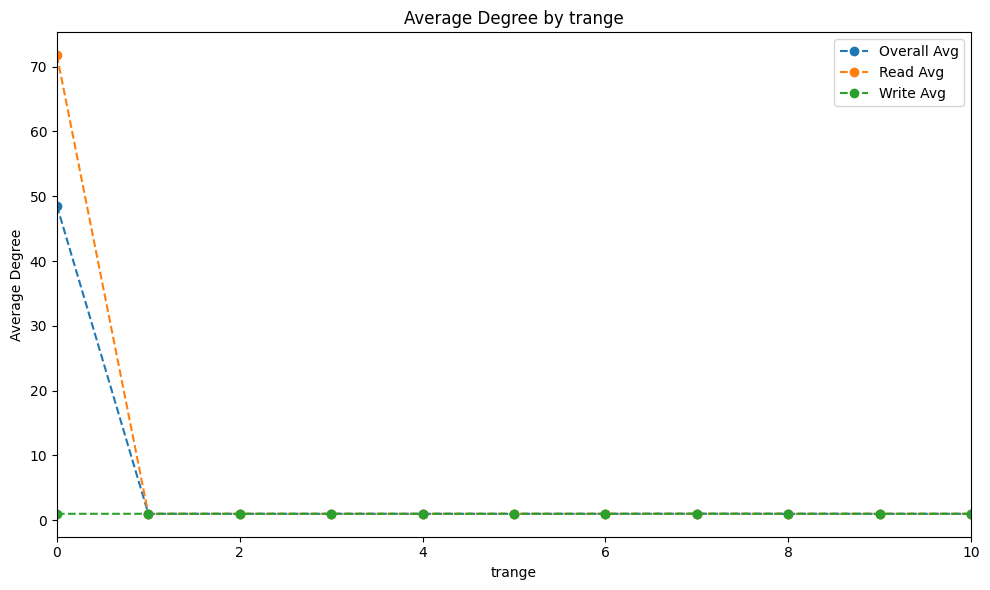

In [71]:
plot_avg_deg(inter)


Our technique indicates that most I/O bursts occur during the time range 0. After this period, read and write events proceed independently, without causing interference with other requests.

## Technique 3 
### Dataflow Graph (Directed Graph)

### a. *What I/O characteristics are we trying to find?* 
Identify the set of processes and files withing a workloads' dataflow that determines the makespan of the workload.

Using this technique, we aim to identify the nodes or files that are crucial in the flow of data between other nodes or files in the workflow. Identifying these key files or processes that control the flow of critical information can be beneficial for addressing various I/O issues, such as identifying bottlenecks and improving fault tolerance, ultimately facilitating performance optimization.


### b. *How do we find these Characteristics? (methodology)* 
We identify these characteristics by first creating the dataflow graph using the I/O traces. We compute betweeness centrality and degree centrality of the nodes 

**Graph Creation**: 

Vertices (Files,Processes)

Edges: Directed edges, process to file; produced or consumed relationship.

Steps of creating graph: 


**Betweeness Centrality**: Frequent intermediatery, Acting as bridge, direct/undirect relationship

**Degree Centrality**: Direct neighbor 


## Technique 3.1 (Abstract dataflow View)  (Runtime Dataflow view)



Abstract may have missed information, 
reduce information, look for runtime view and make sure they match.

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference,IF_val
0,read,104999,8192,330642476,330642491,/p/gpfs1,15,11,1,1,8,0.533333,2
1,read,104999,8192,330642602,330642612,/p/gpfs1,10,11,1,1,8,0.8,1
2,read,104999,8192,330642699,330642708,/p/gpfs1,9,11,1,1,8,0.888889,1
3,read,104999,1506,330642793,330642802,/p/gpfs1,9,11,1,1,9,1.0,1
4,write,104999,33854,330964072,330964253,/p/gpfs1,181,11,1,1,69,0.381215,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18485,read,104999,1048576,11916942177,11916942344,/p/vast1,167,397,1,1,40,0.239521,4
18486,read,104999,22,11916942601,11916942607,/p/vast1,6,397,1,1,5,0.833333,1
18487,read,104999,42,11916942723,11916942728,/p/vast1,5,397,1,1,5,1.0,1
18488,read,104999,250,11916942806,11916942811,/p/vast1,5,397,1,1,5,1.0,1


In [175]:
def scatter_deg_bc(betweenness_centrality, degree, filtered_nodes, pid):
    # 2. Get unique communities from the pid map for filtered nodes
    communities = set(pid[node] for node in filtered_nodes)
    # print(communities)
    
    # 3. Assign a unique color to each community
    color_map = {community: np.random.rand(3,) for community in communities}  # Random color for each community

    # 4. Plot the scatter plot with color-coded communities for filtered nodes
    plt.figure(figsize=(4, 4))

    for community in communities:
        # Filter nodes that belong to this community and start with 'p_'
        community_nodes = [node for node in filtered_nodes if pid[node] == community]
        
        # Get x (degree) and y (betweenness centrality) values for these nodes
        x = [degree[node] for node in community_nodes]
        y = [betweenness_centrality[node] for node in community_nodes]
        # Adding jitter
        jitter = 0.002
        x = [xi + np.random.uniform(-jitter, jitter) for xi in x]
        y = [yi + np.random.uniform(-jitter, jitter) for yi in y]
        # Plot this community's nodes
        plt.scatter(x, y, c=[color_map[community]], s=100, alpha=0.7, label=community)

    # 5. Set x-axis ticks to integers
    plt.xticks(np.arange(min(degree.values()), max(degree.values())+1, 1))

    # Add labels, title, and legend
    plt.xlabel('Degree')
    plt.ylabel('Betweenness Centrality')
    plt.title('Betweenness Centrality vs Degree')
    plt.grid(True)

    # Add legend (community names)
    plt.legend(title='Category', loc='best')

    # Show the plot
    plt.tight_layout()
    plt.show()



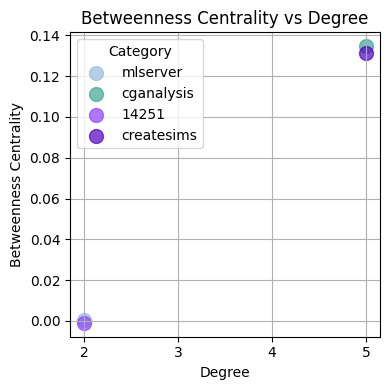

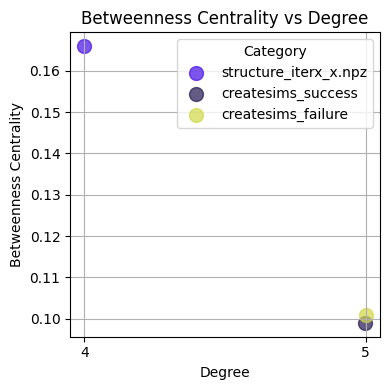

In [178]:
# DO NOT DELETE
graph_df = pd.read_csv("/p/lustre2/pandey2/cp_centrality/mummi/graph_app.csv")
G = nx.from_pandas_edgelist(graph_df, source='src', target='dest', create_using=nx.DiGraph())

pid_map = {i:i[2:] for i in G.nodes()}
communities = G.nodes() #

communities = pid_map.values() 
filtered_p = [node for node in G.nodes() if str(node).startswith('p_')]
filtered_f = [node for node in G.nodes() if str(node).startswith('f_')]
betweenness_centrality = nx.betweenness_centrality(G)
degree_p = dict(G.degree(filtered_p))  # Only for filtered nodes
degree_f = dict(G.degree(filtered_f))  # Only for filtered nodes
scatter_deg_bc(betweenness_centrality, degree_p, filtered_p, pid_map)
scatter_deg_bc(betweenness_centrality, degree_f, filtered_f, pid_map)


In [134]:
wf_obj = DFGrepWorkflow()
wf_obj.trace_path = "/usr/workspace/iopp/graph-io/dlp_logs/mummi-32-node/*pfw.gz"
pid_map = wf_obj.get_pid_map()
# for node in G.nodes():
#     if node[2:] not in pid_map:
#         pid_map[node] = node
# set(pid_map.values())

## Technique 3.2 (Processes View. Actual Graphs)

### *What I/O chaaracteristic can we see from this view?*

### *How is this view different form Application Level View?*
This graph is finer-granularity view where each vertices are individual process ids or distinct files. 

### *Result?*

When comparing the betweenness centrality values of these two views, in the abstract graph, *cganalysis* and *createsims* are seen as critical applications controlling the flow of information. However, in the fine-grained view, where all the PIDs associated with the applications are considered, the PID associated with ML server is observed as the key component directly interacting with multiple files and significantly contributing to the control of information flow across the workflow.


In [138]:
wf_obj = DFGrepWorkflow()
wf_obj.trace_path = "/usr/workspace/iopp/graph-io/dlp_logs/mummi-32-node/*pfw.gz"
pid_map = wf_obj.get_pid_map()
updated_dict = {
    f'f_{key}' if key.startswith('/') else f'p_{key}': value
    for key, value in pid_map.items()
}
for node in G.nodes():
    if node not in updated_dict.keys():
        updated_dict[node] = node


In [168]:
def scatter_deg_bc_finer(betweenness_centrality, degree, filtered_nodes, pid):
    # 2. Get unique communities from the pid map for filtered nodes
    communities = set(pid[node] for node in filtered_nodes)
    # print(communities)
    
    # 3. Assign a unique color to each community
    color_map = {community: np.random.rand(3,) for community in communities}  # Random color for each community

    # 4. Plot the scatter plot with color-coded communities for filtered nodes
    plt.figure(figsize=(4, 4))

    for community in communities:
        # Filter nodes that belong to this community and start with 'p_'
        community_nodes = [node for node in filtered_nodes if pid[node] == community]
        
        # Get x (degree) and y (betweenness centrality) values for these nodes
        x = [degree[node] for node in community_nodes]
        y = [betweenness_centrality[node] for node in community_nodes]
        # Adding jitter
        jitter = 0.002
        x = [xi + np.random.uniform(-jitter, jitter) for xi in x]
        y = [yi + np.random.uniform(-jitter, jitter) for yi in y]
        # Plot this community's nodes
        plt.scatter(x, y, c=[color_map[community]], s=100, alpha=0.7, label=community)

    # 5. Set x-axis ticks to integers
    # plt.xticks(np.arange(min(degree.values()), max(degree.values())+1, 50))
    plt.xticks(np.arange(0, max(degree.values())+1, 50))
    # Add labels, title, and legend
    plt.xlabel('Degree')
    plt.ylabel('Betweenness Centrality')
    plt.title('Betweenness Centrality vs Degree')
    plt.grid(True)

    # Add legend (community names)
    plt.legend(title='Category', loc='best')

    # Show the plot
    plt.tight_layout()
    plt.show()



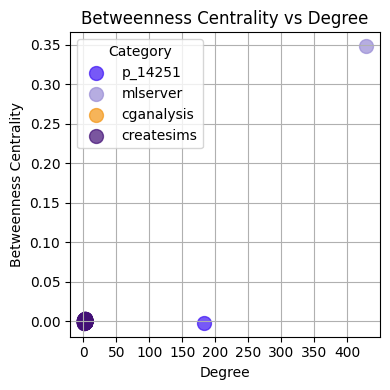

In [173]:
graph_df = pd.read_csv("/p/lustre2/pandey2/cp_centrality/mummi/graph_finer.csv")
G = nx.from_pandas_edgelist(graph_df, source='src', target='dest', create_using=nx.DiGraph())

# pid_map = {i:i[2:] for i in G.nodes()}
# communities = G.nodes() #

# communities = pid_map.values() 
filtered_p = [node for node in G.nodes() if str(node).startswith('p_')]
filtered_f = [node for node in G.nodes() if str(node).startswith('/')]
betweenness_centrality = nx.betweenness_centrality(G)
degree_p = dict(G.degree(filtered_p))  # Only for filtered nodes
degree_f = dict(G.degree(filtered_f))  # Only for filtered nodes
scatter_deg_bc_finer(betweenness_centrality, degree_p, filtered_p, updated_dict)
# scatter_deg_bc_finer(betweenness_centrality, degree_f, filtered_f, updated_dict)